<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# A Neural Network to Classify n-Gons (Vielecke)

This notebook gives the first example of a neural network for a classification task. **Is there a triangle, quadrilateral, pentagon or hexagon in this image?**

<img src="ngon-ex.png" alt="noisy n-gon" width="150"/>
Solution: (expand the next cell)

There is a pentagon.

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pickle # to load 'pickled' numpy arrays (serialized, compressed)
from tensorflow.keras.layers import Dense, Flatten, Input

2025-03-09 17:42:17.608991: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-09 17:42:17.609180: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 17:42:17.611771: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 17:42:17.646753: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-09 17:42:18.279146: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

In [2]:
# load image data as numpy arrays (generated with a separate script available on request)
# Pickling is a way to store data structures on a drive - or cucumbers in a glass.
# load training data
with open("../data/ngons/ngon_train.pkl", "rb") as f:
    Xtrain, ytrain_class = pickle.load(f)
# load test data
with open("../data/ngons/ngon_test.pkl", "rb") as f:
    Xtest, ytest_class = pickle.load(f)

num_train = Xtrain.shape[0]
num_test = Xtest.shape[0]
height = Xtrain.shape[1]
width = Xtrain.shape[2]
img_size_flat = width * height

num_classes = 4 # 0, 1, 2, 3 for 3-, 4-, 5-, 6-gons

# one-hot encode output classes
ytrain = np.eye(num_classes, dtype=float)[ytrain_class]
ytest = np.eye(num_classes, dtype=float)[ytest_class]
print("Fraction of classes:", np.mean(ytrain, axis=0)) # close to 1/4 each

# normalize input to [0,1]
Xtrain = Xtrain / 255.
Xtest = Xtest / 255.

print("Size of training set is", num_train, ", size of test set is", num_test)

# Number of classes
num_classes = 4 # 0, 1, 2, 3 for 3, ..., 6 gons

Fraction of classes: [0.2567 0.2409 0.2502 0.2522]
Size of training set is 10000 , size of test set is 2000


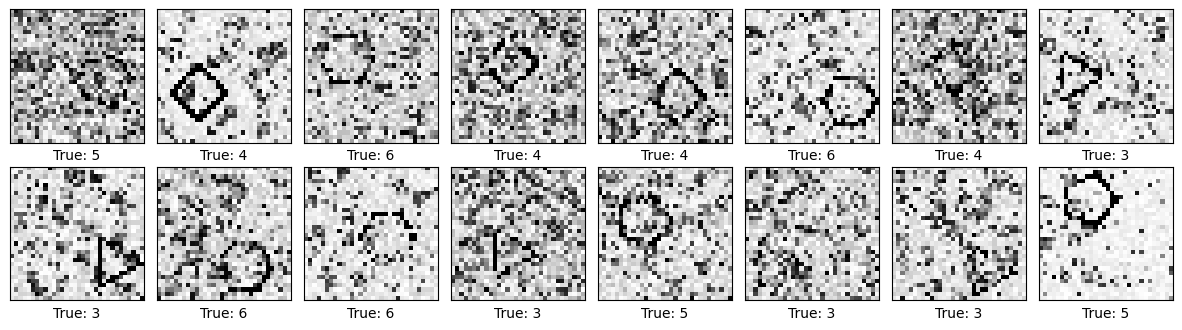

In [3]:
def plot_images(images, class_true, class_pred = None):
    """ Plot 16 (sample) images with their true and predicted classes"""
    assert len(images) == len(class_true) == 16

    # Create figure with sub-plots.
    fig, axes = plt.subplots(2, 8, figsize=(15, 4))
    fig.subplots_adjust(hspace=0.05, wspace=0.1)

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], interpolation = 'none', cmap = 'binary') # plot image

        # display also true and predicted classes
        if class_pred is None:
            xlabel = "True: {0}".format(3 + class_true[i])
        else:
            xlabel = "True: {0}, Pred: {1}".format(3 + class_true[i], 3 + class_pred[i])

        ax.set_xlabel(xlabel)

        # remove ticks from the plot
        ax.set_xticks([])
        ax.set_yticks([])


plot_images(Xtrain[0:16], ytrain_class[0:16])

## Create Datasets

In [4]:
print(Xtrain.shape, ytrain.shape)

(10000, 32, 32) (10000, 4)


In [5]:
# both datasets have batch_size 32, the training data is repeated infinitely
train_ds = tf.data.Dataset.from_tensor_slices((Xtrain, ytrain)).batch(32).repeat()
test_ds = tf.data.Dataset.from_tensor_slices((Xtest, ytest)).batch(32)

2025-03-09 17:42:19.476843: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-09 17:42:19.477542: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Create Neural Network Model
We will use ```tf.keras```, the high-level approach to neural network design and learning. 
As we will repeat the training with different regularization parameters (*weight decay*) we put this into a function.

In [6]:
# Perform the neural network training and report the model, the training history and loss and accuracy on the test set.
   
tf.random.set_seed(12032025) # so we all get the same pseudorandom results

model = tf.keras.models.Sequential()
model.add(Input(shape = (height, width)))

# Flatten unrolls the 2-dim input to a vector of size height * width
model.add(Flatten())

# make a fully connected layer with 3200 units (more on this choice in tomorrow's lecture)
model.add(Dense(3200, activation = tf.nn.relu))

# final layer has one output unit per class
model.add(Dense(4, activation = tf.nn.softmax))

model.summary()

# define the loss, optimization algorithm and prepare the model for gradient computation 
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
 
# execute the actual training
history = model.fit(Xtrain, ytrain, epochs = 25, validation_split = 0.2, verbose = 1) # takes ~5m

test_loss, test_acc = model.evaluate(test_ds)
print("Loss on test set:", test_loss, "\nAccuracy on test set:", test_acc)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3200)           │     3,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │        12,804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,292,804 (12.56 MB)

 Trainable params: 3,292,804 (12.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2440 - loss: 1.6682 - val_accuracy: 0.2375 - val_loss: 1.3927
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2708 - loss: 1.3905 - val_accuracy: 0.2980 - val_loss: 1.3905
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3297 - loss: 1.3765 - val_accuracy: 0.2920 - val_loss: 1.3878
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3735 - loss: 1.3313 - val_accuracy: 0.2860 - val_loss: 1.3919
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4187 - loss: 1.2794 - val_accuracy: 0.2875 - val_loss: 1.4511
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4474 - loss: 1.2348 - val_accuracy: 0.2835 - val_loss: 1.4708
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4606 - loss: 1.2110 - val_accuracy: 0.2940 - val_loss: 1.5079
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4877 - loss: 1.1635 - val_accu

### Plot the training history

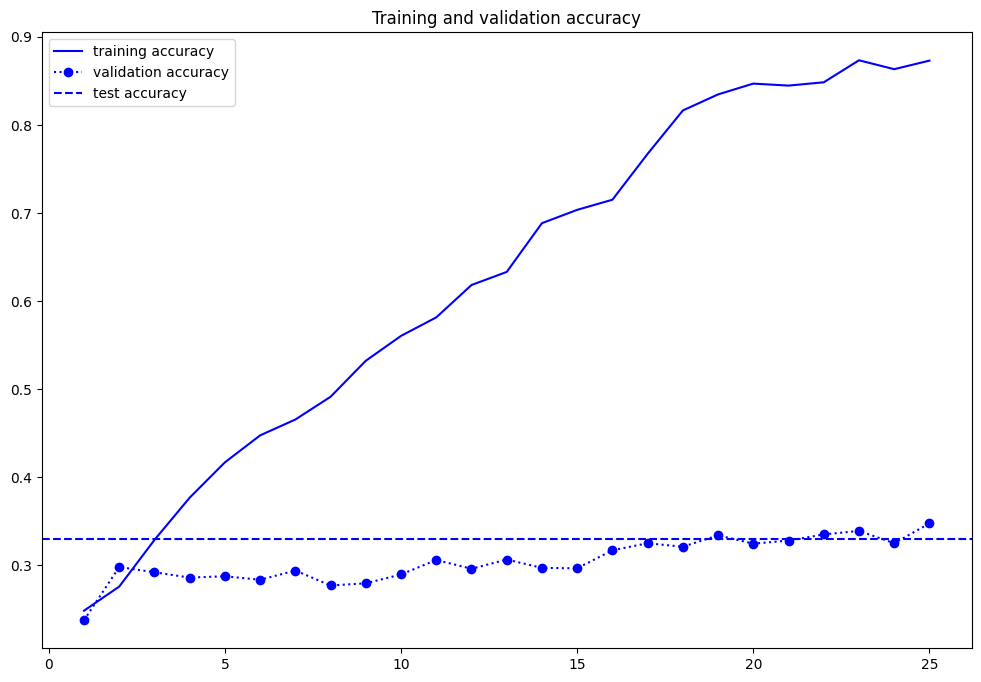

In [7]:
fig, ax = plt.subplots(figsize = (12, 8))

ax.set_title('Training and validation accuracy')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

ax.plot(epochs, acc, color = "blue", label = "training accuracy")
ax.plot(epochs, val_acc, "o:", color = "blue", label = "validation accuracy")
ax.axhline(y = test_acc, color = "blue", linestyle = "--", label = "test accuracy")

ax.legend();

From above plot we see that the model classifies training data much better than test date (overfit). It indicates that a model with fewer parameters or regularization could be better.

# Make Predictions and Examine Errors

Predicted class probabilities for 3, 4, 5, 6 for the first 16 images:
 [[0.017 0.007 0.956 0.02 ]
 [0.595 0.189 0.195 0.021]
 [0.161 0.324 0.449 0.066]
 [0.047 0.193 0.089 0.671]
 [0.09  0.906 0.004 0.   ]
 [0.367 0.269 0.355 0.008]
 [0.254 0.108 0.255 0.384]
 [0.002 0.976 0.017 0.006]
 [0.208 0.017 0.661 0.115]
 [0.457 0.376 0.076 0.091]
 [0.986 0.001 0.01  0.003]
 [0.093 0.642 0.025 0.24 ]
 [0.474 0.355 0.059 0.112]
 [0.53  0.215 0.003 0.252]
 [0.012 0.039 0.939 0.01 ]
 [0.283 0.429 0.286 0.002]]


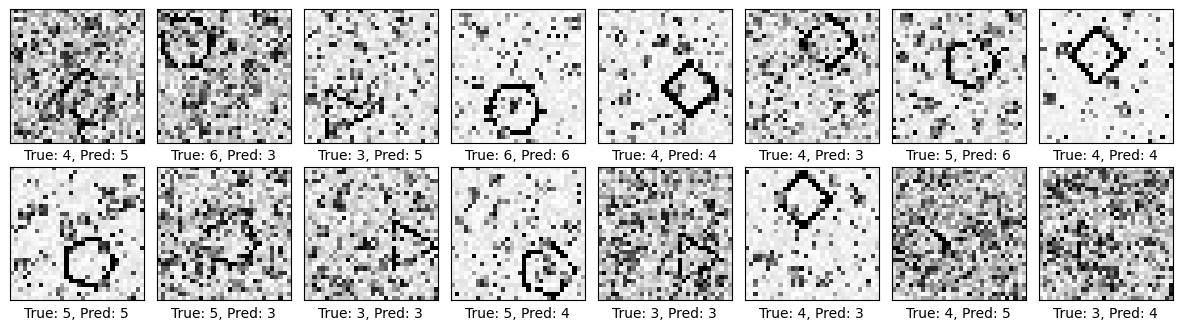

In [8]:
ytest_pred = model(Xtest)
print("Predicted class probabilities for 3, 4, 5, 6 for the first 16 images:\n", ytest_pred[0:16].numpy().round(3))

ytest_predclass = np.argmax(ytest_pred, axis = 1)
plot_images(Xtest[0:16], ytest_class[0:16], ytest_predclass[0:16])

### Not impressed? Wait until tomorrow ...